<a href="https://colab.research.google.com/github/Anusha-Panicker/Web-Content-Mining-for-Automatic-Article-Summarization-Wikipedia-/blob/main/Web_Content_Mining_Automatic_Article_Summarization_(Wikipedia).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Name :- Anusha Panicker**

#**Reg.No :- UST24R0101006**

#**Subject :- DMW (CA 1)**

##**Project Topic :-** Web Content Mining for Automatic Article Summarization (**Wikipedia**)

##**Objective :-** Extract and mine key content patterns from web pages for summarization.

##**Project Description :-** This project focuses on extracting important content from web pages and automatically generating a concise article summary. The system uses **text preprocessing**, **TF-IDF**, **cosine similarity**, and **TextRank** to identify and select the most important sentences from the article. The generated summary is then evaluated using **ROUGE metrics**.

.

#_**Set Up Google Drive and Project Directory**_

In [1]:
# Mount Google Drive to store and access project files.
from google.colab import drive
drive.mount('/content/drive')

import os

# Create the project directory if it does not already exist.
os.makedirs('/content/drive/MyDrive/dmw_project', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##_**Build the Text Summarization Model From Scratch**_

In [2]:
%%writefile /content/drive/MyDrive/dmw_project/summarizer_model.py

# Import required Python libraries
import re
import json
import math
import urllib.request
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap


# ============================================================
# 1. Wikipedia Data Fetching
# ============================================================

class WikiFetcher:

    def _parse_url(self, url):

        # Extract the language and article title from the Wikipedia URL
        parsed = urllib.parse.urlparse(url)
        lang = parsed.netloc.split(".")[0]

        # Support English and Hindi Wikipedia
        if lang not in ("en", "hi"):
            lang = "en"

        title = urllib.parse.unquote(
            parsed.path.split("/wiki/")[-1]
        ).replace("_", " ")

        return lang, title

    def fetch_from_url(self, url):

        # Convert the Wikipedia URL into a Wikipedia API request
        lang, title = self._parse_url(url)
        api_url = f"https://{lang}.wikipedia.org/w/api.php"

        params = {
            "action": "query", "format": "json",
            "prop": "extracts", "explaintext": 1,
            "titles": title
        }

        full_url = api_url + "?" + urllib.parse.urlencode(params)

        # Send the request with a user-agent
        req = urllib.request.Request(
            full_url, headers={"User-Agent": "DMW-Project/1.0"}
        )

        with urllib.request.urlopen(req, timeout=15) as resp:
            data = json.loads(resp.read().decode("utf-8"))

        # Extract the article from the API response
        page = next(iter(data["query"]["pages"].values()))
        text = page.get("extract", "")

        if not text:
            raise ValueError(f"No article found for: {title}")

        return text


# ============================================================
# 2. Text Preprocessing
# ============================================================

class TextPreprocessor:

    # Common words that are removed because they usually
    # provide less useful information for similarity calculation
    STOPWORDS = set("""
    a an the and or but if while is are was were be been being to of in on
    for with as by at from this that these those it its it's he she they
    them his her their we you your i not no nor so than then there here
    which who whom what when where why how all any both each few more most
    other some such only own same can will just do does did doing have has
    had having also into about above below between during before after
    over under again further once
    """.split())

    def split_sentences(self, text):

        # Remove Wikipedia-style section headings
        text = re.sub(r"={2,}.*?={2,}", " ", text)

        # Remove unnecessary spaces and line breaks
        text = re.sub(r"\s+", " ", text).strip()

        # Split the article into individual sentences
        raw = re.split(r"(?<=[.!?])\s+(?=[A-Z(])", text)

        # Remove very short sentences
        return [s.strip() for s in raw if len(s.strip()) > 20]

    def clean_tokens(self, sentence):

        # Convert text to lowercase and remove special characters
        sentence = re.sub(r"[^a-z0-9\s]", " ", sentence.lower())

        # Tokenize the sentence and remove stopwords
        return [t for t in sentence.split()
                if t not in self.STOPWORDS and len(t) > 1]


# ============================================================
# 3. TF-IDF Vectorization From Scratch
# ============================================================

class TFIDFVectorizer:
    def __init__(self):
        self.vocab_, self.idf_ = {}, None

    def fit(self, tokenized_docs):

        # Create a vocabulary containing every unique word
        vocab = {}
        for doc in tokenized_docs:
            for tok in set(doc):
                vocab[tok] = vocab.get(tok, 0) + 1

        # Assign a unique index to every vocabulary word
        self.vocab_ = {t: i for i, t in enumerate(vocab)}
        n = len(tokenized_docs)

        # Calculate IDF values.
        # vocab[term] represents the number of sentences
        # containing that term.
        self.idf_ = np.zeros(len(self.vocab_))
        for term, i in self.vocab_.items():
            self.idf_[i] = math.log(
                (n + 1) / (vocab[term] + 1)
            ) + 1

        return self

    def transform(self, tokenized_docs):

        # Create an empty TF matrix
        tf = np.zeros((len(tokenized_docs), len(self.vocab_)))

        for i, doc in enumerate(tokenized_docs):
            if not doc:
                continue

            # Count word occurrences in the sentence
            counts = {}
            for tok in doc:
                counts[tok] = counts.get(tok, 0) + 1

            # Calculate Term Frequency (TF)
            for term, count in counts.items():
                if term in self.vocab_:
                    tf[i, self.vocab_[term]] = count / len(doc)

        # Combine TF and IDF to obtain TF-IDF vectors
        return tf * self.idf_

    def fit_transform(self, tokenized_docs):

        # Fit the vocabulary and calculate TF-IDF
        return self.fit(tokenized_docs).transform(tokenized_docs)


# ============================================================
# 4. TextRank Summarization
# ============================================================

class TextRankSummarizer:
    def __init__(self, damping=0.85, max_iter=100, tol=1e-4):
        self.damping, self.max_iter, self.tol = damping, max_iter, tol
        self.preprocessor = TextPreprocessor()
        self.vectorizer = TFIDFVectorizer()
        self.sentences_, self.scores_ = None, None

    @staticmethod
    def _cosine_similarity(a, b):

        # Calculate cosine similarity between two sentences
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        return np.dot(a, b) / denom if denom else 0.0

    def _build_similarity_matrix(self, tfidf):

        # Create a matrix showing similarity between sentences
        n = len(tfidf)
        sim = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                if i != j:
                    sim[i, j] = self._cosine_similarity(tfidf[i], tfidf[j])

        # Normalize similarity scores so each row sums to 1
        row_sums = sim.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return sim / row_sums

    def _pagerank(self, sim):

        # Initialize all sentences with equal importance
        n = len(sim)
        scores = np.ones(n) / n

        # Iteratively update sentence importance scores
        for _ in range(self.max_iter):
            new = (1-self.damping)/n + self.damping * sim.T.dot(scores)

            # Stop when the scores have almost converged
            if np.abs(new - scores).sum() < self.tol:
                scores = new
                break
            scores = new

        return scores

    def fit(self, article_text):

        # Split the article into sentences
        self.sentences_ = self.preprocessor.split_sentences(article_text)

        # Convert every sentence into cleaned tokens
        tokens = [self.preprocessor.clean_tokens(s) for s in self.sentences_]

        # Convert sentences into TF-IDF vectors
        tfidf = self.vectorizer.fit_transform(tokens)

        # Build sentence similarity graph and rank sentences
        self.scores_ = self._pagerank(
            self._build_similarity_matrix(tfidf)
        )
        return self

    def predict(self, top_n=4):

        # Select the sentences with the highest TextRank scores
        # Sort selected sentences by their original position
        # so that the final summary follows article order
        idx = sorted(np.argsort(-self.scores_)[:top_n])
        return " ".join(self.sentences_[i] for i in idx)


# ============================================================
# 5. ROUGE Evaluation From Scratch
# ============================================================

class ROUGEEvaluator:

    @staticmethod
    def _ngrams(tokens, n):

        # Generate n-grams from a list of tokens
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

    def rouge_n(self, candidate, reference, n):

        # Convert candidate and reference into lowercase tokens
        c, r = candidate.lower().split(), reference.lower().split()
        cg, rg = self._ngrams(c, n), self._ngrams(r, n)

        if not cg or not rg:
            return {"precision": 0.0, "recall": 0.0, "f1": 0.0}


        # Count n-gram occurrences
        rc, cc = {}, {}
        for g in rg:
            rc[g] = rc.get(g, 0) + 1
        for g in cg:
            cc[g] = cc.get(g, 0) + 1

        # Calculate overlapping n-grams
        overlap = sum(min(x, rc.get(g, 0)) for g, x in cc.items())

        # Calculate precision and recall
        p, r = overlap/len(cg), overlap/len(rg)

        # Calculate F1 score
        f1 = 2*p*r/(p+r) if p+r else 0.0

        return {"precision": p, "recall": r, "f1": f1}

    def _lcs_length(self, a, b):

        # Calculate the Longest Common Subsequence (LCS)
        m, n = len(a), len(b)
        dp = np.zeros((m+1, n+1), dtype=int)

        for i in range(1, m+1):
            for j in range(1, n+1):
                dp[i,j] = (dp[i-1,j-1] + 1 if a[i-1] == b[j-1]
                           else max(dp[i-1,j], dp[i,j-1]))
        return int(dp[m,n])

    def rouge_l(self, candidate, reference):

        # Tokenize candidate and reference summaries
        c, r = candidate.lower().split(), reference.lower().split()

        if not c or not r:
            return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

        # Find the length of the longest common subsequence
        lcs = self._lcs_length(c, r)
        p, r = lcs/len(c), lcs/len(r)

        # Calculate ROUGE-L F1 score
        f1 = 2*p*r/(p+r) if p+r else 0.0

        return {"precision": p, "recall": r, "f1": f1}

    def evaluate(self, candidate, reference):

        # Calculate multiple ROUGE metrics
        return {
            "ROUGE-1": self.rouge_n(candidate, reference, 1),
            "ROUGE-2": self.rouge_n(candidate, reference, 2),
            "ROUGE-L": self.rouge_l(candidate, reference)
        }


# ============================================================
# 6. Complete Summarization Pipeline
# ============================================================

def summarize_url(url, top_n=5):
    """One call: fetch -> summarize -> evaluate. This is all you need after setup."""

    # Step 1: Fetch the article from Wikipedia
    fetcher = WikiFetcher()
    article_text = fetcher.fetch_from_url(url)

    # For demonstration, the first line of the article
    # is used as a proxy reference summary.
    # A real evaluation should use a human-written reference.
    reference_summary = article_text.split("\n")[0]

    # Step 2: Create and train the TextRank model
    model = TextRankSummarizer(damping=0.85)
    model.fit(article_text)

    # Step 3: Generate the extractive summary
    summary = model.predict(top_n=top_n)

    # Step 4: Evaluate the generated summary
    evaluator = ROUGEEvaluator()
    scores = evaluator.evaluate(summary, reference_summary)

    # Return all important results
    return {
        "summary": textwrap.fill(summary, width=100),
        "reference": reference_summary,
        "rouge_scores": pd.DataFrame(scores).T,
        "sentence_scores": model.scores_,
    }

Writing /content/drive/MyDrive/dmw_project/summarizer_model.py


##_**Import and Verify the Custom Model**_

In [3]:
# Add the project folder to Python's search path
# so that Python can find our custom summarizer_model.py file.
import sys
sys.path.append('/content/drive/MyDrive/dmw_project')

# Import the custom summarization module created for this project.
import summarizer_model

# Reload the module to make sure the latest changes are being used
import importlib
importlib.reload(summarizer_model)

# Import the main function used to generate a summary from a URL.
from summarizer_model import summarize_url

# Confirm that the custom module was imported successfully.
print("Module loaded successfully ✅")

Module loaded successfully ✅


##_**Select the Input Article and Generate the Summary**_

In [4]:
# Define the Wikipedia article that will be used as input.
url = "https://en.wikipedia.org/wiki/Quantum_computing"

# Set the number of sentences to include in the final summary.
TOP_N_SENTENCES = 10

# Import the classes required for fetching, summarizing, and evaluating the article.
from summarizer_model import WikiFetcher, TextRankSummarizer, ROUGEEvaluator
import textwrap
import pandas as pd

# Create an object to fetch the article from the given URL.
fetcher = WikiFetcher()
article_text = fetcher.fetch_from_url(url)

# Use the first line of the article as a simple reference summary
# for calculating ROUGE scores.
reference_summary = article_text.split("\n")[0]

# Create the TextRank summarizer with a damping factor of 0.85.
summarizer = TextRankSummarizer(damping=0.85)

# Process the article and calculate the importance of each sentence.
summarizer.fit(article_text)

# Select the 10 most important sentences as the generated summary.
generated_summary = summarizer.predict(TOP_N_SENTENCES)

# Display the total number of sentences and the summary size.
print(f"\nSummary: top {TOP_N_SENTENCES} of "
      f"{len(summarizer.sentences_)} sentences")

# Display the generated extractive summary in a readable format.
print("--- GENERATED SUMMARY ---")
print(textwrap.fill(generated_summary, width=100))

# Evaluate the generated summary using the manually implemented ROUGE evaluator.
scores = ROUGEEvaluator().evaluate(generated_summary, reference_summary)

# Display the ROUGE evaluation scores in table format.
print(pd.DataFrame(scores).T)


Summary: top 10 of 337 sentences
--- GENERATED SUMMARY ---
A quantum computer is a computer that represents and processes information using quantum states. The
basic unit of information in quantum computing, the qubit (quantum bit), serves a similar function
as the bit in ordinary or "classical" computing. Physicist Charlie Bennett noted that since
classical computers are composed of quantum atoms, one might study them from the opposite direction:
A classical computer is a quantum computer ... so we shouldn't be asking about "where do quantum
speedups come from?" We should say, "Well, all computers are quantum. ... A quantum gate array
decomposes computation into a sequence of few-qubit quantum gates. All of these models of
computation—quantum circuits, one-way quantum computation, adiabatic quantum computation, and
topological quantum computation—have been shown to be equivalent to the quantum Turing machine;
given a perfect implementation of one such quantum computer, it can simulat

##_**Visualize ROUGE and Sentence Importance Scores**_

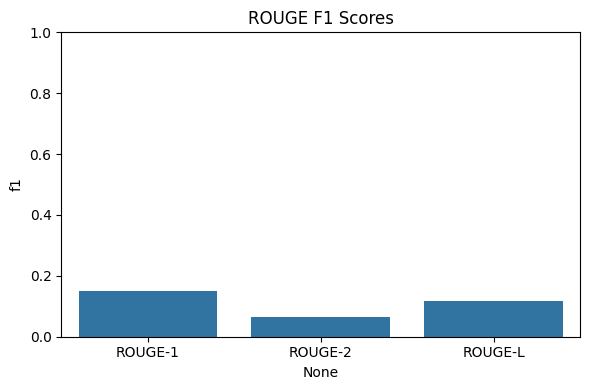

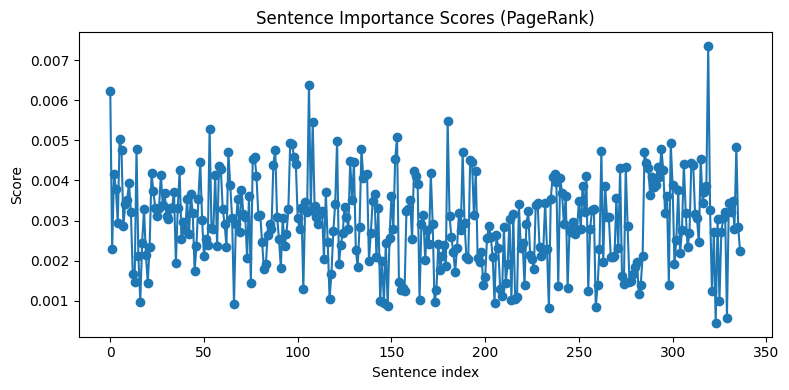

In [5]:
# Import libraries used for creating visualizations.
import matplotlib.pyplot as plt
import seaborn as sns

# Run the complete summarization pipeline and store the results.
result = summarize_url(url, top_n=TOP_N_SENTENCES)

# Plot the ROUGE F1 scores.
plt.figure(figsize=(6, 4))
sns.barplot(x=result["rouge_scores"].index, y=result["rouge_scores"]["f1"])
plt.title("ROUGE F1 Scores"); plt.ylim(0, 1); plt.tight_layout(); plt.show()

# Plot the sentence importance scores calculated by PageRank
plt.figure(figsize=(8, 4))
plt.plot(result["sentence_scores"], marker="o")
plt.title("Sentence Importance Scores (PageRank)")
plt.xlabel("Sentence index"); plt.ylabel("Score")
plt.tight_layout(); plt.show()

##_**Small Example to Verify the Algorithm**_

In [6]:
from summarizer_model import TextRankSummarizer

# Define a small example to verify the TextRank summarization algorithm.
demo_text = "Cats are small animals. Cats like to sleep a lot. Dogs are loyal animals."
demo = TextRankSummarizer()

# Fit the model and calculate sentence importance scores.
demo.fit(demo_text)

print("Sentences:", demo.sentences_)
print("Vocabulary:", list(demo.vectorizer.vocab_.keys()))
print("Final importance scores:", demo.scores_)

# Generate a summary containing the two most important sentences.
print("Summary:", demo.predict(top_n=2))

Sentences: ['Cats are small animals.', 'Cats like to sleep a lot.', 'Dogs are loyal animals.']
Vocabulary: ['animals', 'cats', 'small', 'like', 'lot', 'sleep', 'dogs', 'loyal']
Final importance scores: [0.48650659 0.23984437 0.27364904]
Summary: Cats are small animals. Dogs are loyal animals.
